<a href="https://colab.research.google.com/github/beleja05/neuraldata_Amanda/blob/main/coding_homework_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Amanda Belej
*Introduction to Neural Data Analysis *

**April 10th 2026**


In [43]:
#this imports needed libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as pearsonr
from pandas import DataFrame as df

In [44]:
#This imports the data as np arrays
urlfear = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/fear_conditioning_traces_hw8.csv'
urlex = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/extinction_predictors_hw8.csv'
urlsh = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/shock_index.csv'
urltone = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/tone_index.csv'
fear_traces = np.loadtxt(urlfear, delimiter = ',')
extinction_predictors = np.loadtxt(urlex, delimiter = ',')
shock_index = np.loadtxt(urlsh, delimiter = ',')
tone_index = np.loadtxt(urltone, delimiter = ',')

In [45]:
#this creates arrays for conditioning and extintion from the fear_traces array
conditioning_traces = fear_traces[0:10458,:]
extinction_traces = fear_traces[10459:,:]

In [46]:
#this shows the shape of each array
print(conditioning_traces.shape)
print(extinction_traces.shape)

(10458, 63)
(14209, 63)


In [47]:
#this shows the time of the conditioning and extinction period when it was captured at 15 fps and make time variables
samples_con = conditioning_traces.shape[0]
duration_con = (samples_con - 1) / 15
time_conditioning = np.linspace(0, duration_con, samples_con)

samples_ex = extinction_traces.shape[0]
duration_ex = (samples_ex - 1) / 15
time_extinction = np.linspace(0, duration_ex, samples_ex)

print(duration_con)
print(duration_ex)

697.1333333333333
947.2


There were 63 ROIs. The conditioning lasted 697 seconds (11.55 minutes) and extinction lasted 947 seconds (15.8 minutes)

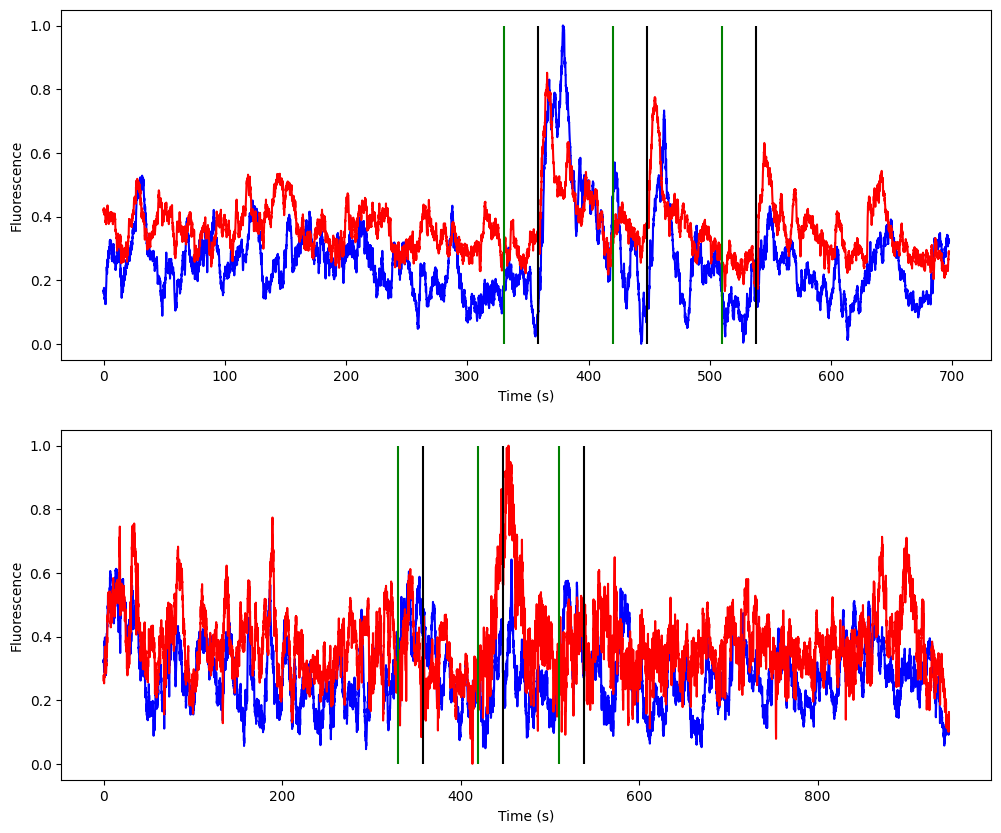

In [48]:
#this plots the first and second ROIs with the first in blue and second in red. The top graph is for conditioning while the bottom graph is for extinction. Shocks are indicated in black and tones are indicated in green
fps = 15

plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
plt.plot(time_conditioning, conditioning_traces[:, 0], color='blue')
plt.plot(time_conditioning, conditioning_traces[:, 1], color='red')

plt.vlines(shock_index, 0, 1, color = 'black')
plt.vlines(tone_index, 0, 1, color = 'green')

plt.xlabel('Time (s)')
plt.ylabel('Fluorescence')


plt.subplot(2, 1, 2)
plt.plot(time_extinction, extinction_traces[:, 0], color='blue')
plt.plot(time_extinction, extinction_traces[:, 1], color='red')

plt.vlines(shock_index, 0, 1, color = 'black')
plt.vlines(tone_index, 0, 1, color = 'green')
plt.xlabel('Time (s)')
plt.ylabel('Fluorescence')
plt.show()

The first ROI does not act the same in conditioning versus extinction. In conditioning it seemed to have high fluorescence after the shocks, but not in the extinction. Same is true with the second ROI, showing the first and second ROI behave similary. Neither showed distinct patterns in extinction.

In [49]:

#This makes shock and tone arrays and creates the conditioning predictors variable
shock_array = np.zeros(10458)
for i in range(10458):
  if i >= (shock_index[0]-15)*15 and i <= (shock_index[0]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[1]-15)*15 and i <= (shock_index[1]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[2]-15)*15 and i <= (shock_index[2]+30)*15:
    shock_array[i] = 1
  else:
    shock_array[i] = 0

tone_array = np.zeros(10458)
for i in range(10458):
  if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
    tone_array[i] = 1
  else:
    tone_array[i] = 0


  predictors_conditioning = df(data={'Intercept': np.ones_like(tone_array), 'tone onset': tone_array})
  predictors_conditioning['shock onset'] = shock_array

In [50]:
#This calculates the correlation coefficents for conditioning
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson
from scipy.stats import pearsonr

r_index_conditioning = np.zeros(63)

for i in range(63):
  trace_temp = conditioning_traces[:,i]
  model3 = sm.GLM(trace_temp, predictors_conditioning, family=Poisson())
  model3_results = model3.fit()
  predicted_trace = model3_results.predict()
  r3 = pearsonr(trace_temp, predicted_trace)
  r_index_conditioning[i] = r3.statistic

In [56]:

#This creates the extinction predictor then calculates the correlation coefficents for conditioning

shock_array = np.zeros(14209)
for i in range(14209):
  if i >= (shock_index[0]-15)*15 and i <= (shock_index[0]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[1]-15)*15 and i <= (shock_index[1]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[2]-15)*15 and i <= (shock_index[2]+30)*15:
    shock_array[i] = 1
  else:
    shock_array[i] = 0

tone_array = np.zeros(14209)
for i in range(14209):
  if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
    tone_array[i] = 1
  else:
    tone_array[i] = 0

extinction_predictors = df(data={'Intercept': np.ones_like(shock_array), 'shock onset': shock_array})
extinction_predictors['tone onset'] = tone_array

r_index_extinction = np.zeros(63)

for i in range(63):
  trace_temp = extinction_traces[:,i]
  model3 = sm.GLM(trace_temp, extinction_predictors, family=Poisson())
  model3_results = model3.fit()
  predicted_trace = model3_results.predict()
  r3 = pearsonr(trace_temp, predicted_trace)
  r_index_extinction[i] = r3.statistic

In [59]:
#This correlates the conditioning to extinction
from scipy.stats import pearsonr

correlation_result = pearsonr(r_index_conditioning, r_index_extinction)
print(correlation_result)

PearsonRResult(statistic=np.float64(0.4399336389518285), pvalue=np.float64(0.0003088241965266274))


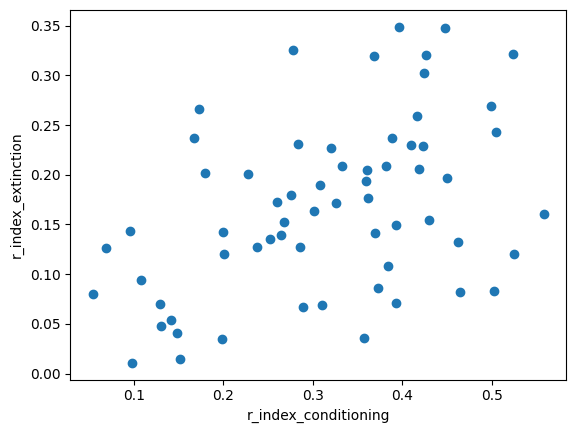

In [60]:
#this plots the relationship between conditioning and extinction
import matplotlib.pyplot as plt

plt.scatter(r_index_conditioning, r_index_extinction)
plt.xlabel('r_index_conditioning')
plt.ylabel('r_index_extinction')
plt.show()

The p-value is 0.0003, showing that there is a statistically significant relationship. The scatterplot seems to support this by having a bit of a positive correlation. This means that cells that increase in conditioning after stimuli will likely increase during extinction too